In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## EDA

In [2]:
df = pd.read_feather("lending_club_clean.feather")

In [3]:
import pandas as pd

df = pd.read_feather("lending_club_clean.feather")

print(df.columns.tolist())

['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot

In [4]:
df.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag
0,1077501,5000,5000,4975.0,36,0.1065,162.869995,B,B2,NaN,...,NaT,NaT,NaT,-1,-1,NaN,-1.0,-1.0,-1.0,N
1,1077430,2500,2500,2500.0,60,0.1527,59.830002,C,C4,Ryder,...,NaT,NaT,NaT,-1,-1,NaN,-1.0,-1.0,-1.0,N
2,1077175,2400,2400,2400.0,36,0.1596,84.330002,C,C5,NaN,...,NaT,NaT,NaT,-1,-1,NaN,-1.0,-1.0,-1.0,N
3,1076863,10000,10000,10000.0,36,0.1349,339.309998,C,C1,AIR RESOURCES BOARD,...,NaT,NaT,NaT,-1,-1,NaN,-1.0,-1.0,-1.0,N
4,1075358,3000,3000,3000.0,60,0.1269,67.790001,B,B5,University Medical Group,...,NaT,NaT,NaT,-1,-1,NaN,-1.0,-1.0,-1.0,N


In [5]:
df.shape

(2925492, 141)

In [6]:
df.isnull().sum()

id                                                  0
loan_amnt                                           0
funded_amnt                                         0
funded_amnt_inv                                     0
term                                                0
                                               ...   
hardship_loan_status                          2782081
orig_projected_additional_accrued_interest          0
hardship_payoff_balance_amount                      0
hardship_last_payment_amount                        0
debt_settlement_flag                                0
Length: 141, dtype: int64

In [7]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

hardship_loan_status                          95.097884
hardship_reason                               95.090330
hardship_status                               95.090228
hardship_type                                 95.090125
hardship_start_date                           95.090125
                                                ...    
hardship_dpd                                   0.000000
orig_projected_additional_accrued_interest     0.000000
hardship_payoff_balance_amount                 0.000000
hardship_last_payment_amount                   0.000000
debt_settlement_flag                           0.000000
Length: 141, dtype: float64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2925492 entries, 0 to 2925491
Columns: 141 entries, id to debt_settlement_flag
dtypes: Int16(54), Int32(15), Int64(15), category(22), datetime64[ns](9), float32(26)
memory usage: 1.8 GB


In [9]:
df.describe()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,annual_inc,issue_d,dti,...,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount
count,2925492.0,2925492.0,2925492.0,2.925492e+06,2925492.0,2.925492e+06,2.925492e+06,2.925492e+06,2925492,2.925492e+06,...,2925492.0,2.925492e+06,143638,143638,143638,2925492.0,2925492.0,2.925492e+06,2.925492e+06,2.925492e+06
mean,97829692.164153,15358.775105,15354.704909,1.534005e+04,43.099647,1.304545e-01,4.523914e+02,7.993716e+04,2017-01-30 21:20:26.304498944,1.927386e+01,...,-0.841243,6.523758e+00,2020-02-05 11:16:16.805581312,2020-04-10 10:38:38.127516416,2020-02-10 06:12:26.175804928,-0.841243,-0.836839,2.169180e+01,7.454874e+02,4.546077e+01
min,54734.0,500.0,500.0,0.000000e+00,36.0,5.310000e-02,4.930000e+00,-1.000000e+00,2007-06-01 00:00:00,-2.000000e+00,...,-1.0,-1.000000e+00,2017-01-01 00:00:00,2017-03-01 00:00:00,2017-02-01 00:00:00,-1.0,-1.0,-1.000000e+00,-1.000000e+00,-1.000000e+00
25%,59131974.0,8000.0,8000.0,8.000000e+03,36.0,9.170000e-02,2.535000e+02,4.700000e+04,2015-09-01 00:00:00,1.206000e+01,...,-1.0,-1.000000e+00,2020-04-01 00:00:00,2020-06-01 00:00:00,2020-04-01 00:00:00,-1.0,-1.0,-1.000000e+00,-1.000000e+00,-1.000000e+00
50%,107610658.5,13000.0,13000.0,1.300000e+04,36.0,1.249000e-01,3.823000e+02,6.600000e+04,2017-05-01 00:00:00,1.808000e+01,...,-1.0,-1.000000e+00,2020-04-01 00:00:00,2020-06-01 00:00:00,2020-04-01 00:00:00,-1.0,-1.0,-1.000000e+00,-1.000000e+00,-1.000000e+00
75%,143220179.75,20000.0,20000.0,2.000000e+04,60.0,1.599000e-01,6.039200e+02,9.500000e+04,2018-11-01 00:00:00,2.487000e+01,...,-1.0,-1.000000e+00,2020-04-01 00:00:00,2020-07-01 00:00:00,2020-05-01 00:00:00,-1.0,-1.0,-1.000000e+00,-1.000000e+00,-1.000000e+00
max,171017115.0,40000.0,40000.0,4.000000e+04,60.0,3.099000e-01,1.719830e+03,1.100000e+08,2020-09-01 00:00:00,9.990000e+02,...,4.0,2.797500e+03,2020-10-01 00:00:00,2021-02-01 00:00:00,2020-11-01 00:00:00,4.0,82.0,1.158182e+04,4.213555e+04,4.027098e+04
std,51163328.917654,9478.383451,9477.144689,9.480635e+03,10.953839,4.860815e-02,2.729478e+02,1.117476e+05,NaN,1.572673e+01,...,0.709815,6.830856e+01,NaN,NaN,NaN,0.709815,1.546101,1.461113e+02,3.690746e+03,5.529636e+02


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique()

id                                            2925492
loan_amnt                                        1572
funded_amnt                                      1572
funded_amnt_inv                                 10033
term                                                2
                                               ...   
hardship_loan_status                               14
orig_projected_additional_accrued_interest      93481
hardship_payoff_balance_amount                 164106
hardship_last_payment_amount                    51184
debt_settlement_flag                                2
Length: 141, dtype: int64

In [12]:
df['loan_status'].value_counts()

loan_status
Fully Paid                                             1497783
Current                                                1031016
Charged Off                                             362548
Late (31-120 days)                                       16154
In Grace Period                                          10028
Late (16-30 days)                                         2719
Issued                                                    2062
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                    433
Name: count, dtype: int64

In [13]:
df['loan_status'].value_counts(normalize=True)*100

loan_status
Fully Paid                                             51.197645
Current                                                35.242482
Charged Off                                            12.392719
Late (31-120 days)                                      0.552181
In Grace Period                                         0.342780
Late (16-30 days)                                       0.092942
Issued                                                  0.070484
Does not meet the credit policy. Status:Fully Paid      0.067954
Does not meet the credit policy. Status:Charged Off     0.026013
Default                                                 0.014801
Name: proportion, dtype: float64

In [14]:
numerical_cols = df.select_dtypes(include=np.number).columns

print(numerical_cols)


Index(['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'annual_inc', 'dti', 'delinq_2yrs',
       ...
       'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths',
       'sec_app_collections_12_mths_ex_med', 'deferral_term',
       'hardship_amount', 'hardship_length', 'hardship_dpd',
       'orig_projected_additional_accrued_interest',
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount'],
      dtype='str', length=110)


In [15]:
categorical_cols = df.select_dtypes(include='object').columns

print(categorical_cols)

Index([], dtype='str')


In [16]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print(categorical_cols)

Index(['grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership',
       'verification_status', 'loan_status', 'pymnt_plan', 'url', 'purpose',
       'title', 'zip_code', 'addr_state', 'initial_list_status',
       'application_type', 'verification_status_joint', 'hardship_flag',
       'hardship_type', 'hardship_reason', 'hardship_status',
       'hardship_loan_status', 'debt_settlement_flag'],
      dtype='str')


In [17]:
df.dtypes.value_counts()

Int16             54
float32           26
Int64             15
Int32             15
datetime64[ns]     9
category           2
category           2
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
Name: count, dtype: int64

In [18]:
df["annual_inc"].describe()

count    2.925492e+06
mean     7.993716e+04
std      1.117476e+05
min     -1.000000e+00
25%      4.700000e+04
50%      6.600000e+04
75%      9.500000e+04
max      1.100000e+08
Name: annual_inc, dtype: float64

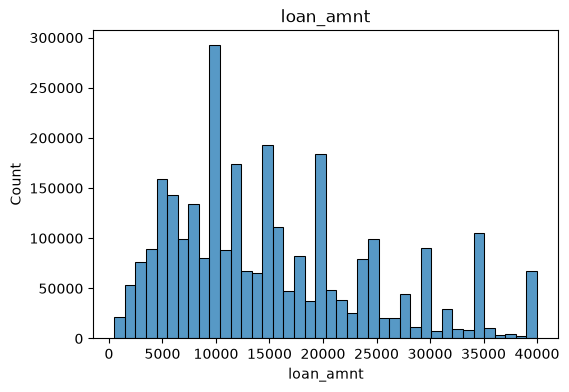

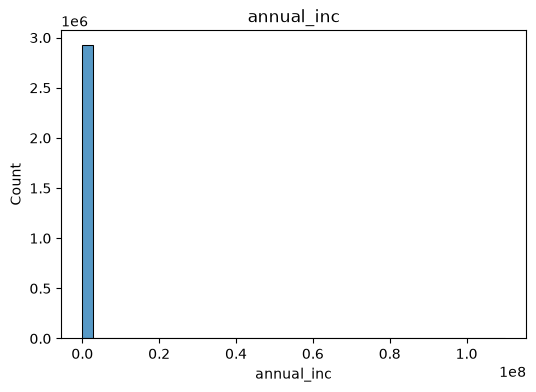

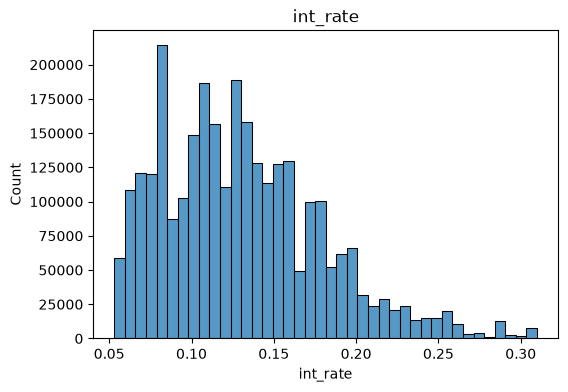

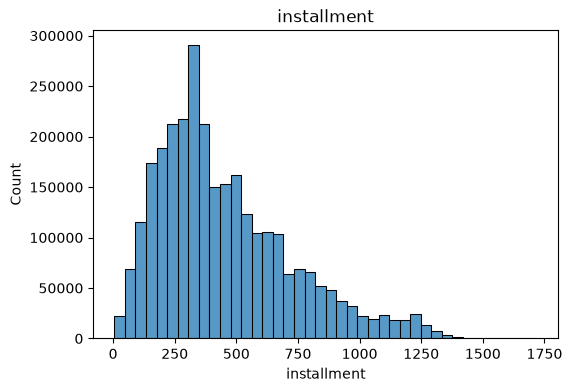

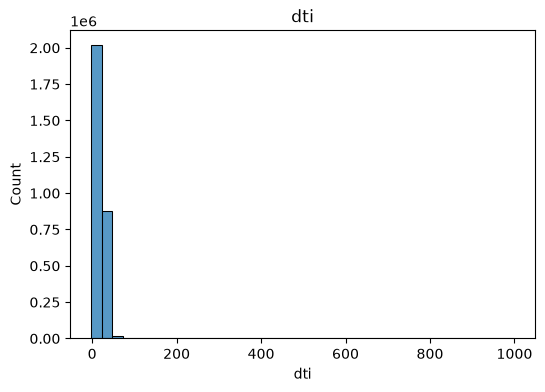

In [19]:
important = [
    "loan_amnt",
    "annual_inc",
    "int_rate",
    "installment",
    "dti"
]

for col in important:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=40)
    plt.title(col)
    plt.show()

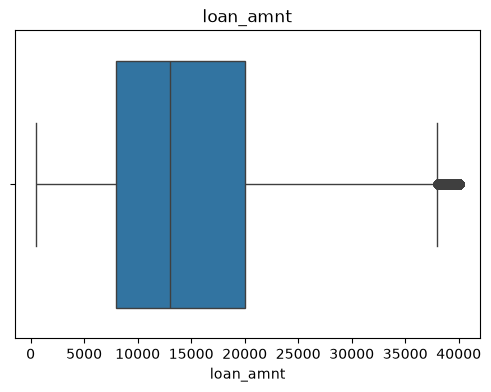

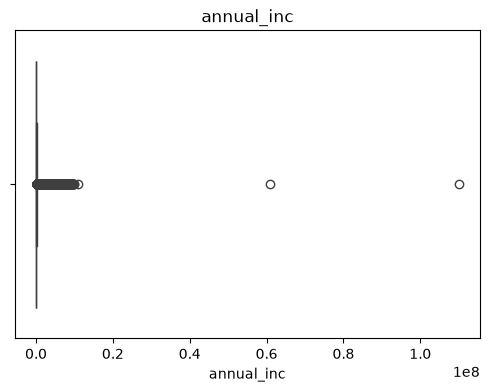

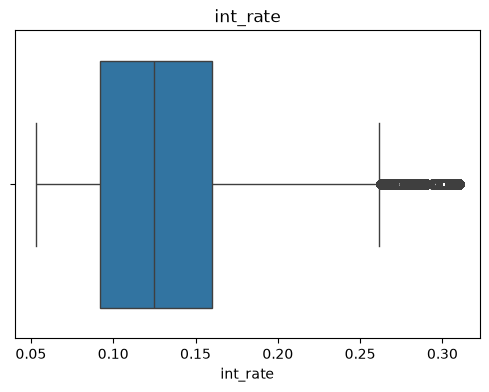

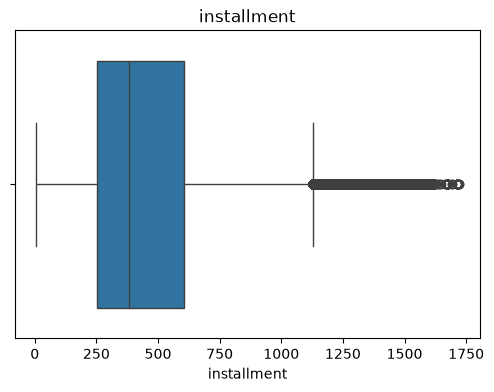

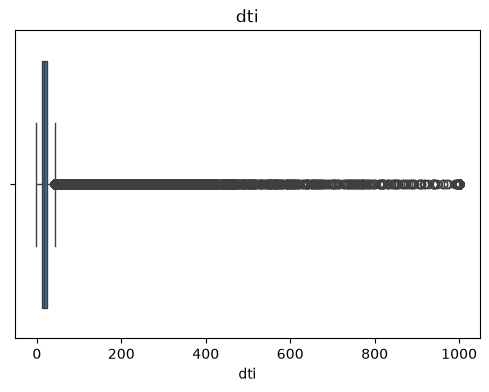

In [20]:
for col in important:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [21]:
(df["annual_inc"] == -1).sum()

np.int64(4)

C:\Users\KARTHIK\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


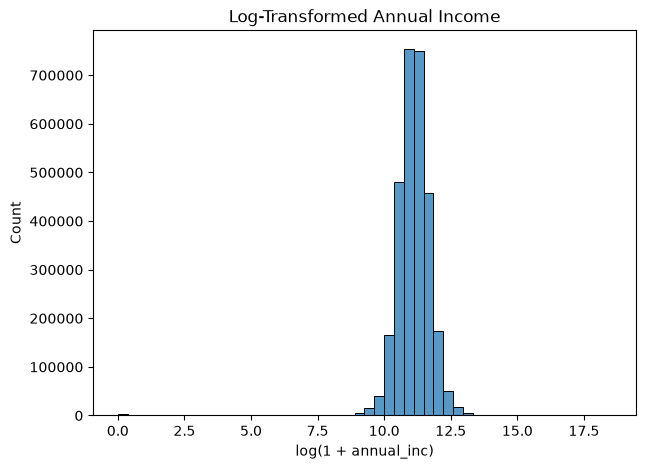

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.histplot(np.log1p(df["annual_inc"]), bins=50)
plt.title("Log-Transformed Annual Income")
plt.xlabel("log(1 + annual_inc)")
plt.ylabel("Count")
plt.show()

In [23]:
corr = df.select_dtypes(include=np.number).corr()

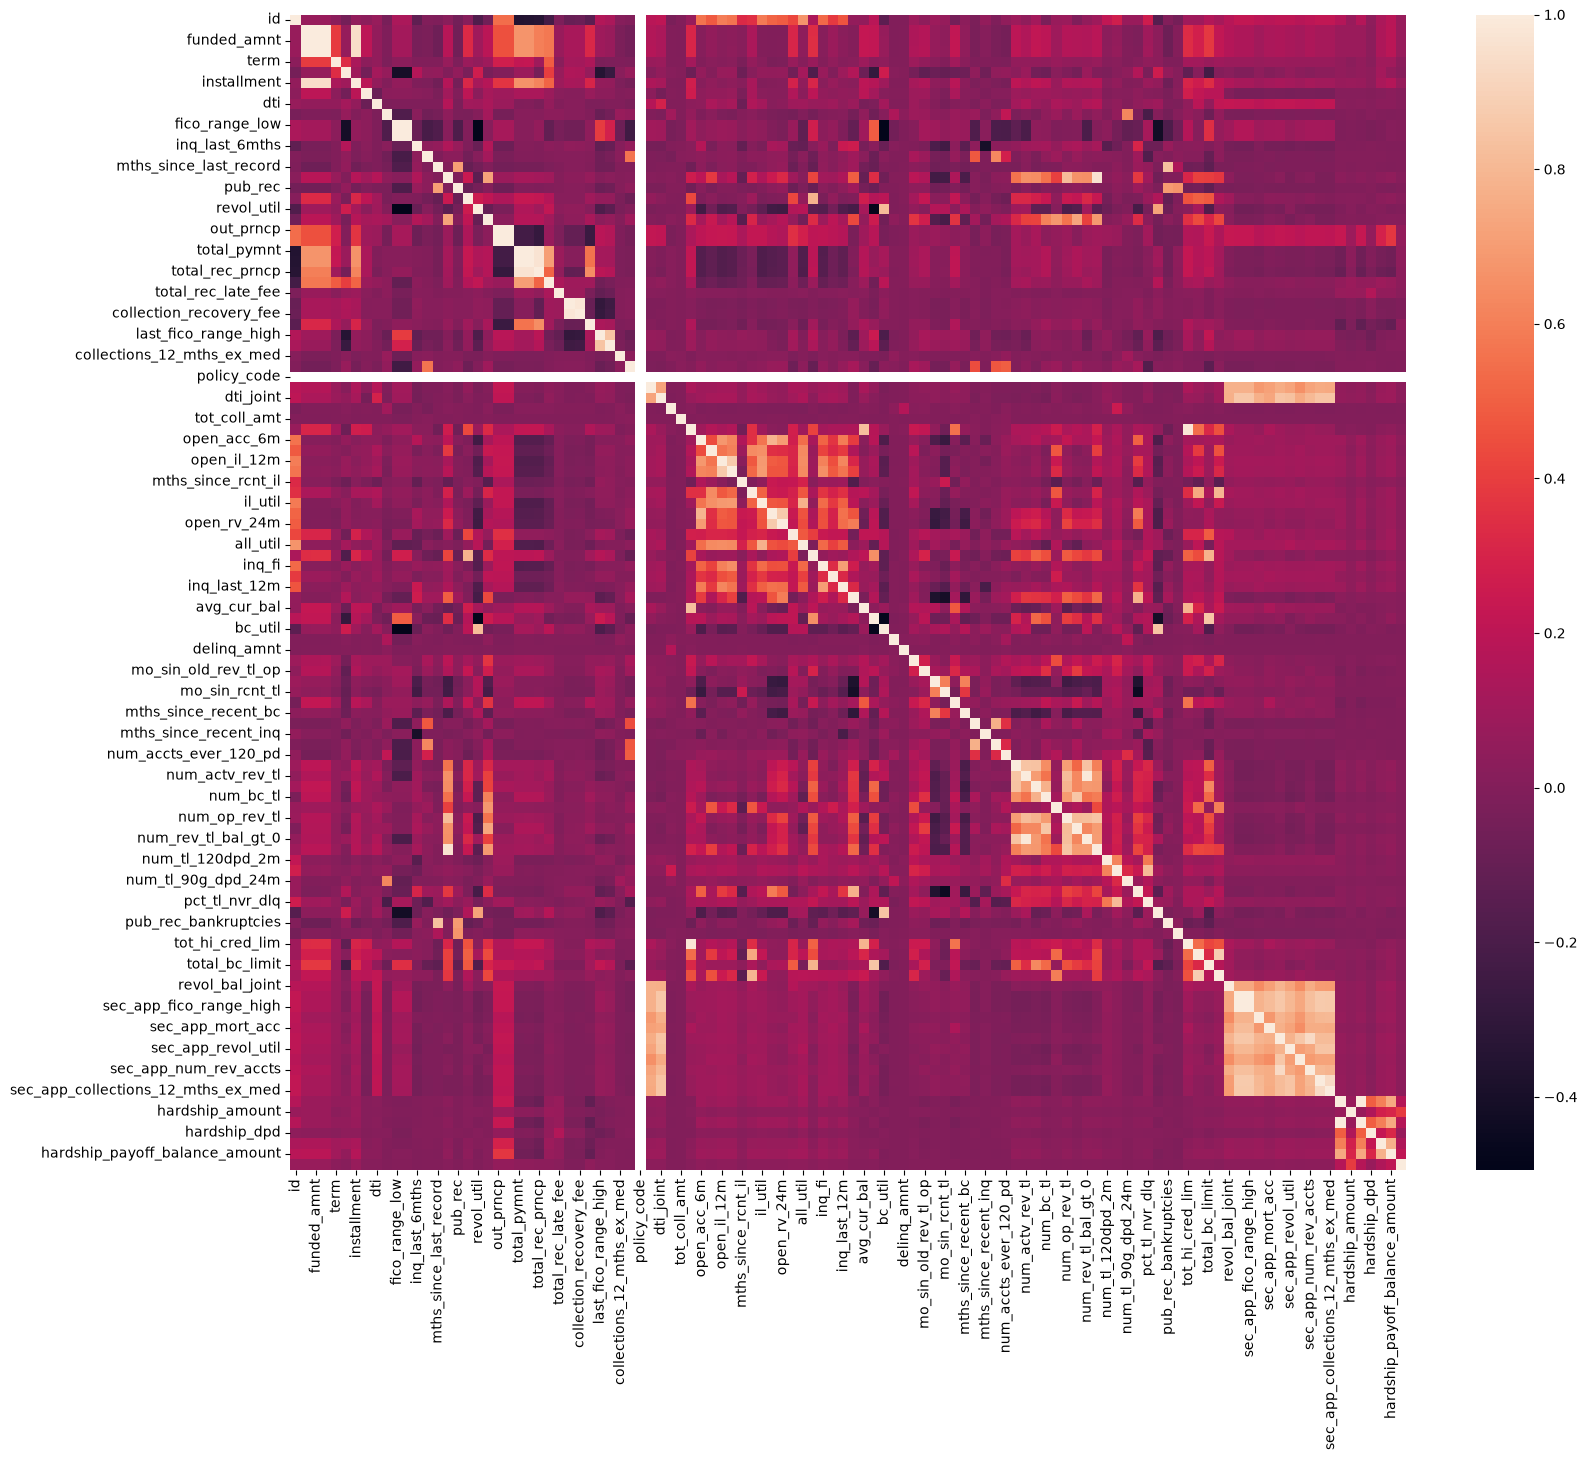

In [24]:
plt.figure(figsize=(18,15))

sns.heatmap(corr)

plt.show()

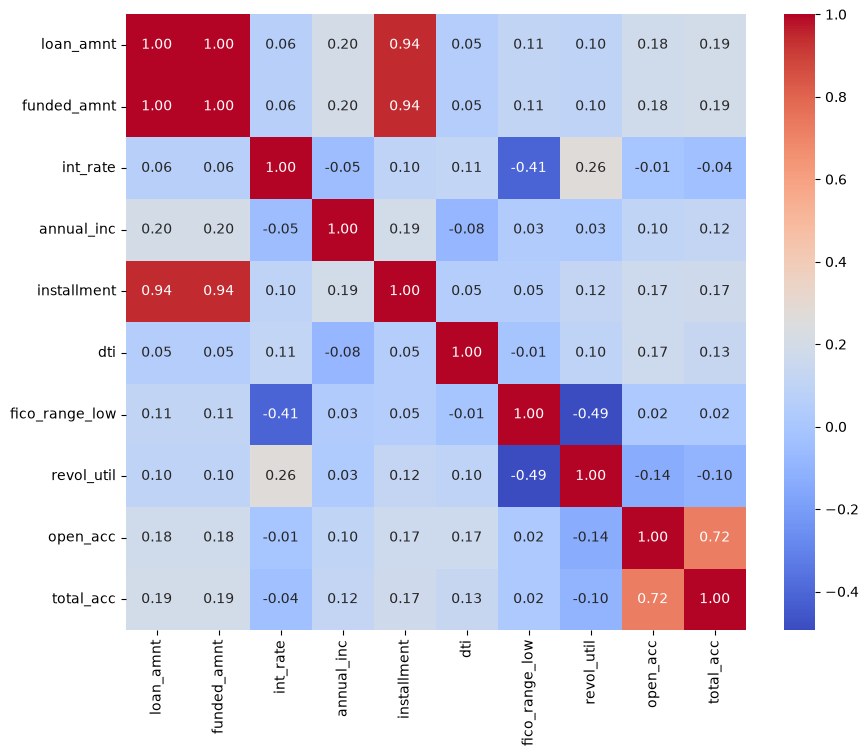

In [25]:
important = [
    "loan_amnt",
    "funded_amnt",
    "int_rate",
    "annual_inc",
    "installment",
    "dti",
    "fico_range_low",
    "revol_util",
    "open_acc",
    "total_acc"
]

plt.figure(figsize=(10,8))
sns.heatmap(df[important].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [26]:
important_cat = [
    "loan_status",
    "grade",
    "purpose",
    "home_ownership",
    "verification_status",
    "application_type",
    "term"
]

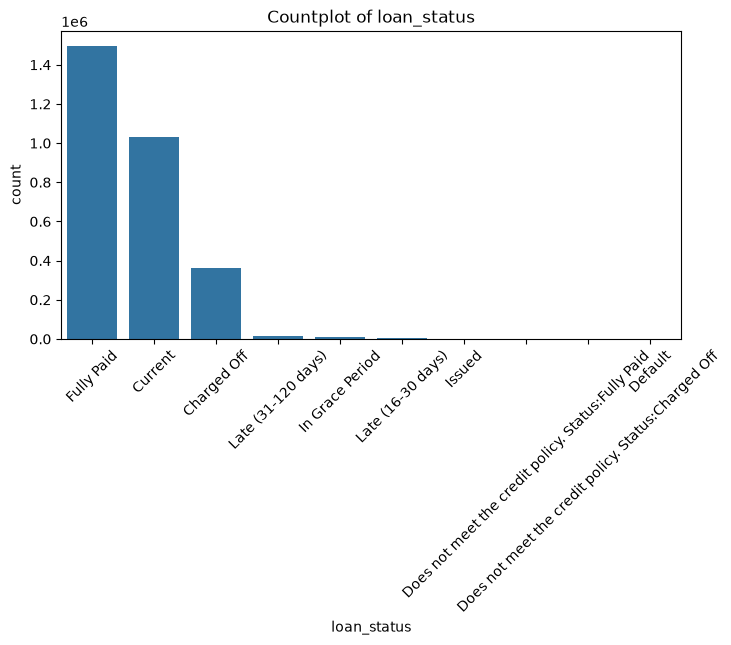

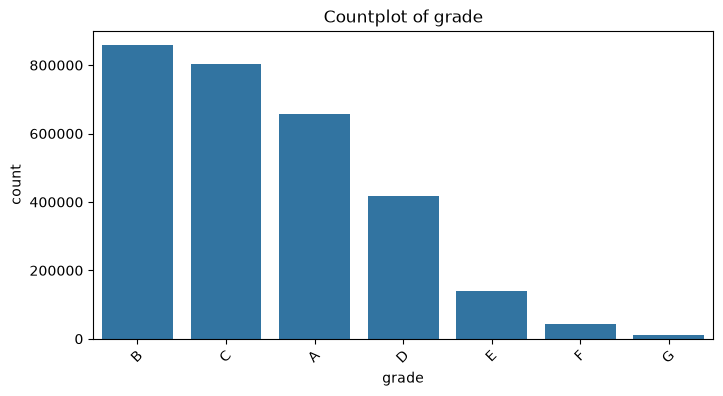

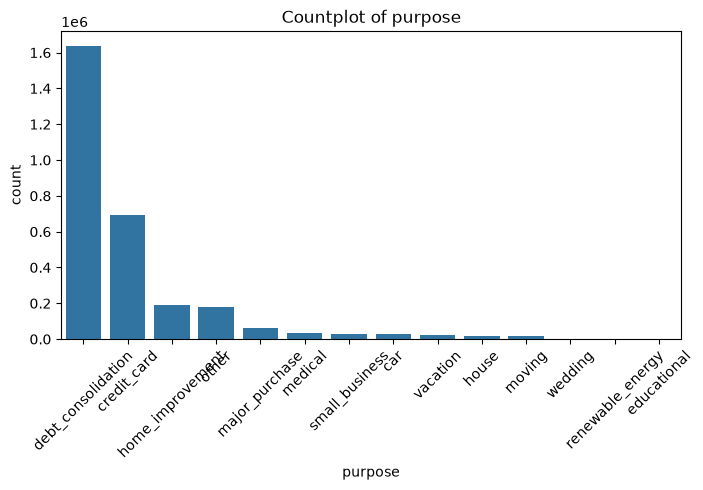

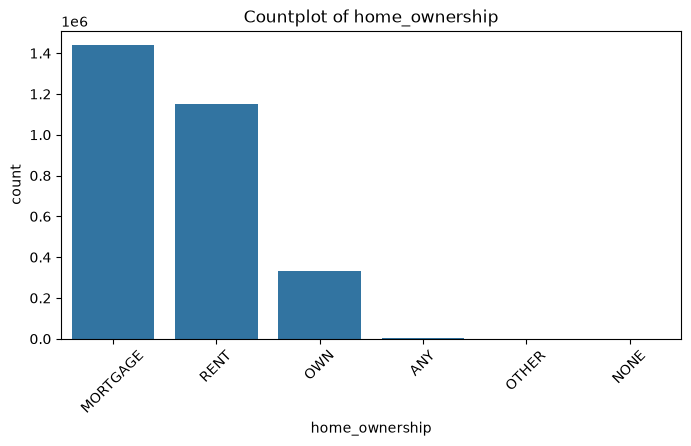

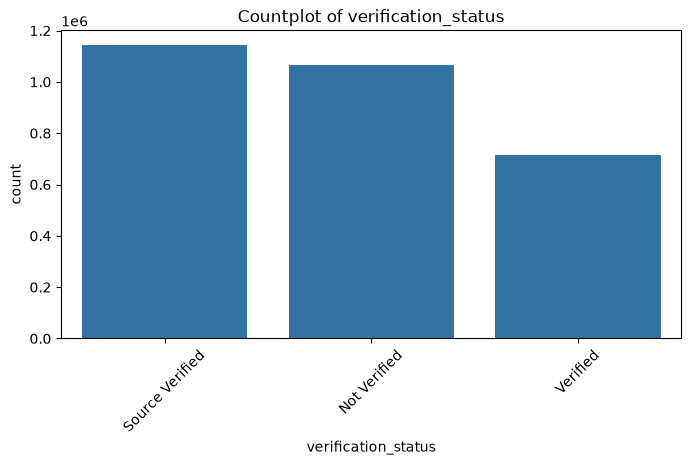

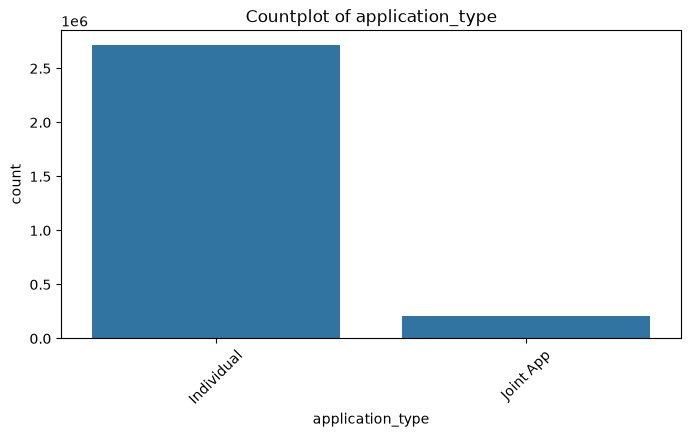

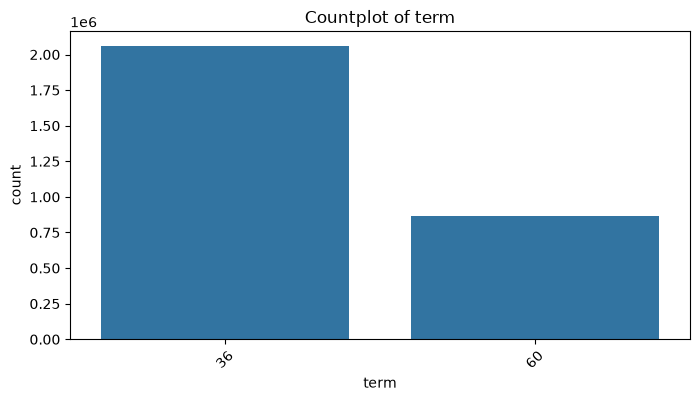

In [27]:
for col in important_cat:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.show()

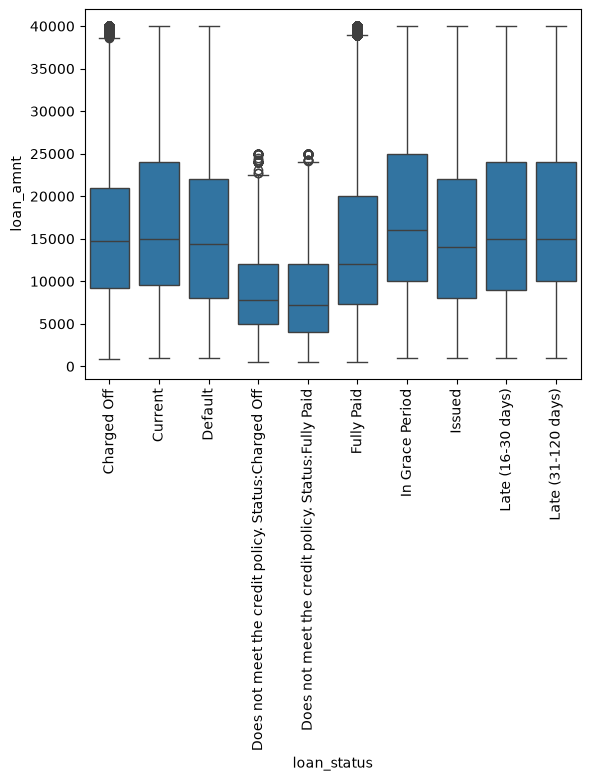

In [28]:
sns.boxplot(x="loan_status", y="loan_amnt", data=df)
plt.xticks(rotation=90)
plt.show()

In [29]:
df["loan_status"].value_counts()

loan_status
Fully Paid                                             1497783
Current                                                1031016
Charged Off                                             362548
Late (31-120 days)                                       16154
In Grace Period                                          10028
Late (16-30 days)                                         2719
Issued                                                    2062
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                    433
Name: count, dtype: int64

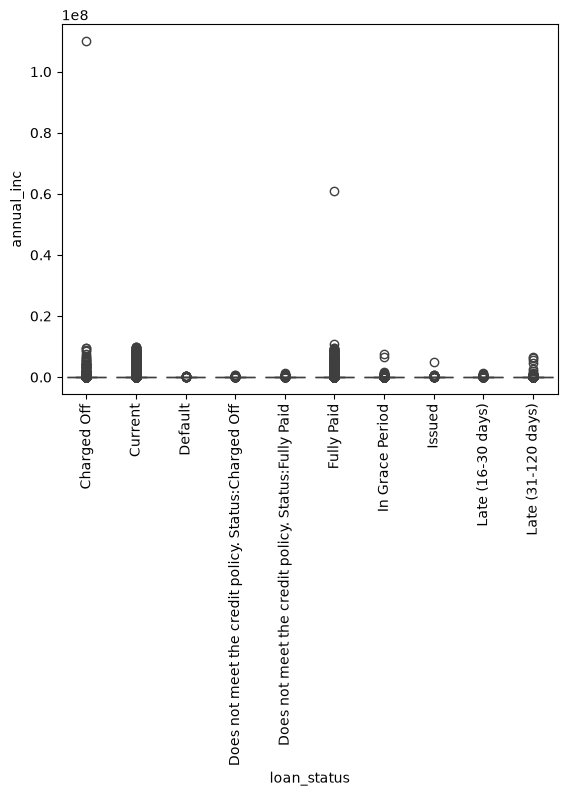

In [30]:
sns.boxplot(x="loan_status", y="annual_inc", data=df)
plt.xticks(rotation=90)
plt.show()

C:\Users\KARTHIK\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


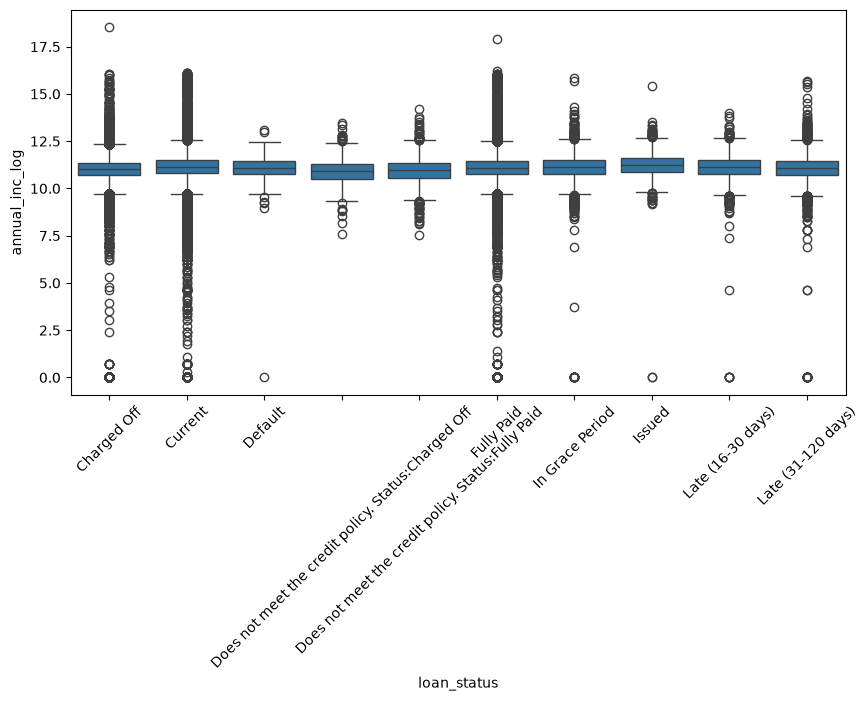

In [31]:
df["annual_inc_log"] = np.log1p(df["annual_inc"])

plt.figure(figsize=(10,5))
sns.boxplot(x="loan_status", y="annual_inc_log", data=df)
plt.xticks(rotation=45)
plt.show()

## FEATURE ENGINEERING

In [32]:
import pandas as pd
import numpy as np
df = pd.read_feather("lending_club_clean.feather")

In [33]:
good_loan = [
    "Fully Paid",
    "Does not meet the credit policy. Status:Fully Paid"
]

bad_loan = [
    "Charged Off",
    "Default",
    "Does not meet the credit policy. Status:Charged Off"
]

# Keep only good/bad loans
df = df[df["loan_status"].isin(good_loan + bad_loan)].copy()

# Convert from Categorical to string
df["loan_status"] = df["loan_status"].astype(str)

# Map to binary
mapping = {
    "Fully Paid": 0,
    "Does not meet the credit policy. Status:Fully Paid": 0,
    "Charged Off": 1,
    "Default": 1,
    "Does not meet the credit policy. Status:Charged Off": 1
}

df["loan_status"] = df["loan_status"].map(mapping)

# Check the result
print(df["loan_status"].value_counts(dropna=False))
print(df["loan_status"].dtype)

loan_status
0    1499771
1     363742
Name: count, dtype: int64
int64


In [34]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing

next_pymnt_d                 1860331
hardship_loan_status         1850817
payment_plan_start_date      1850806
hardship_status              1850806
hardship_end_date            1850806
hardship_type                1850806
hardship_start_date          1850806
hardship_reason              1850805
sec_app_earliest_cr_line     1804843
verification_status_joint    1796174
emp_title                     131687
emp_length                    117294
title                          21408
hardship_flag                   9407
last_pymnt_d                    3301
revol_util                      1438
last_credit_pull_d                67
earliest_cr_line                  29
zip_code                           1
dtype: int64

In [35]:
threshold = len(df) * 0.5

cols_to_drop = missing[missing > threshold].index

df.drop(columns=cols_to_drop, inplace=True)

print("Dropped:", len(cols_to_drop), "columns")

Dropped: 10 columns


In [36]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing

emp_title             131687
emp_length            117294
title                  21408
hardship_flag           9407
last_pymnt_d            3301
revol_util              1438
last_credit_pull_d        67
earliest_cr_line          29
zip_code                   1
dtype: int64

In [37]:
drop_cols = [
    "id",
    "member_id",
    "url",
    "desc",
    "title",
    "zip_code"
]

df.drop(columns=drop_cols, inplace=True, errors="ignore")

In [38]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing

emp_title             131687
emp_length            117294
hardship_flag           9407
last_pymnt_d            3301
revol_util              1438
last_credit_pull_d        67
earliest_cr_line          29
dtype: int64

In [39]:
df.drop(columns=["emp_title"], inplace=True)

print("emp_title dropped successfully!")

emp_title dropped successfully!


In [40]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing

emp_length            117294
hardship_flag           9407
last_pymnt_d            3301
revol_util              1438
last_credit_pull_d        67
earliest_cr_line          29
dtype: int64

In [41]:
df.drop(columns=["last_pymnt_d"], inplace=True)

In [42]:
df.drop(columns=["last_credit_pull_d"], inplace=True)

In [43]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing

emp_length          117294
hardship_flag         9407
revol_util            1438
earliest_cr_line        29
dtype: int64

In [44]:
numerical_cols = df.select_dtypes(include=["int64","float64"]).columns

categorical_cols = df.select_dtypes(include=["object"]).columns

print("Numerical:", len(numerical_cols))
print("Categorical:", len(categorical_cols))

Numerical: 15
Categorical: 0


In [45]:
df.dtypes.value_counts()

Int16             54
float32           26
Int32             15
Int64             14
datetime64[ns]     2
category           2
category           1
category           1
category           1
category           1
category           1
int64              1
category           1
category           1
category           1
category           1
category           1
Name: count, dtype: int64

In [46]:
import numpy as np

numerical_cols = df.select_dtypes(include=np.number).columns

categorical_cols = df.select_dtypes(include=["category", "object"]).columns

datetime_cols = df.select_dtypes(include=["datetime"]).columns

print("Numerical:", len(numerical_cols))
print("Categorical:", len(categorical_cols))
print("Datetime:", len(datetime_cols))

Numerical: 110
Categorical: 12
Datetime: 2


In [47]:
df[numerical_cols].isnull().sum().sort_values(ascending=False)

revol_util                                    1438
loan_amnt                                        0
funded_amnt_inv                                  0
term                                             0
int_rate                                         0
                                              ... 
hardship_length                                  0
hardship_dpd                                     0
orig_projected_additional_accrued_interest       0
hardship_payoff_balance_amount                   0
hardship_last_payment_amount                     0
Length: 110, dtype: int64

In [48]:
df[categorical_cols].isnull().sum().sort_values(ascending=False)

emp_length              117294
hardship_flag             9407
sub_grade                    0
grade                        0
home_ownership               0
verification_status          0
purpose                      0
pymnt_plan                   0
addr_state                   0
initial_list_status          0
application_type             0
debt_settlement_flag         0
dtype: int64

In [49]:
df[datetime_cols].isnull().sum().sort_values(ascending=False)

earliest_cr_line    29
issue_d              0
dtype: int64

In [50]:
df["revol_util"].describe()

count    1.862075e+06
mean     5.046758e-01
std      2.479568e-01
min      0.000000e+00
25%      3.160000e-01
50%      5.050000e-01
75%      6.960000e-01
max      8.923000e+00
Name: revol_util, dtype: float64

In [51]:
df["revol_util"] = df["revol_util"].fillna(df["revol_util"].median())

In [52]:
df["revol_util"].isnull().sum()

np.int64(0)

In [53]:
df["emp_length"].value_counts(dropna=False)

emp_length
10+ years    611932
2 years      168894
< 1 year     154204
3 years      149577
1 year       123312
NaN          117294
5 years      116066
4 years      112441
6 years       85513
8 years       78766
7 years       78253
9 years       67261
Name: count, dtype: int64

In [54]:
df["emp_length"] = (
    df["emp_length"]
    .astype(str)
    .str.replace("10\\+ years", "10", regex=True)
    .str.replace("< 1 year", "0", regex=False)
    .str.replace(" years", "", regex=False)
    .str.replace(" year", "", regex=False)
)

In [55]:
df["emp_length"] = pd.to_numeric(df["emp_length"], errors="coerce")

In [56]:
df["emp_length"]

0          10.0
1           0.0
2          10.0
3          10.0
4           1.0
           ... 
2925487     0.0
2925488    10.0
2925489     8.0
2925490     5.0
2925491     4.0
Name: emp_length, Length: 1863513, dtype: float64

In [57]:
df["emp_length"] = df["emp_length"].fillna(df["emp_length"].median())

In [58]:
print(df["emp_length"].dtype)
print(df["emp_length"].isnull().sum())
print(df["emp_length"].unique())

float64
0
[10.  0.  1.  3.  8.  9.  4.  5.  6.  2.  7.]


In [59]:
df["earliest_cr_line"].head()

0   1985-01-01
1   1999-04-01
2   2001-11-01
3   1996-02-01
4   1996-01-01
Name: earliest_cr_line, dtype: datetime64[ns]

In [60]:
df["earliest_cr_line"].dtype

dtype('<M8[ns]')

In [61]:
df["issue_d"].head()

0   2011-12-01
1   2011-12-01
2   2011-12-01
3   2011-12-01
4   2011-12-01
Name: issue_d, dtype: datetime64[ns]

In [62]:
df["credit_history_length"] = (
    df["issue_d"].dt.year - df["earliest_cr_line"].dt.year
)

In [63]:
df["issue_month"] = df["issue_d"].dt.month

In [64]:
df["issue_year"] = df["issue_d"].dt.year

In [65]:
df.drop(columns=["earliest_cr_line", "issue_d"], inplace=True)

In [66]:
df[["credit_history_length", "issue_year", "issue_month"]].head()

,credit_history_length,issue_year,issue_month
0,26.0,2011,12
1,12.0,2011,12
2,10.0,2011,12
3,15.0,2011,12
4,15.0,2011,12


In [67]:
print(categorical_cols)

Index(['grade', 'sub_grade', 'emp_length', 'home_ownership',
       'verification_status', 'pymnt_plan', 'purpose', 'addr_state',
       'initial_list_status', 'application_type', 'hardship_flag',
       'debt_settlement_flag'],
      dtype='str')


In [68]:
categorical_cols = df.select_dtypes(
    include=["category", "object"]
).columns

categorical_cols

Index(['grade', 'sub_grade', 'home_ownership', 'verification_status',
       'pymnt_plan', 'purpose', 'addr_state', 'initial_list_status',
       'application_type', 'hardship_flag', 'debt_settlement_flag'],
      dtype='str')

In [69]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


grade
['B', 'C', 'A', 'E', 'F', 'D', 'G']
Categories (7, str): ['A', 'B', 'C', 'D', 'E', 'F', 'G']

sub_grade
['B2', 'C4', 'C5', 'C1', 'B5', ..., 'G3', 'G2', 'G1', 'F5', 'G5']
Length: 35
Categories (35, str): ['A1', 'A2', 'A3', 'A4', ..., 'G2', 'G3', 'G4', 'G5']

home_ownership
['RENT', 'OWN', 'MORTGAGE', 'OTHER', 'NONE', 'ANY']
Categories (6, str): ['ANY', 'MORTGAGE', 'NONE', 'OTHER', 'OWN', 'RENT']

verification_status
['Verified', 'Source Verified', 'Not Verified']
Categories (3, str): ['Not Verified', 'Source Verified', 'Verified']

pymnt_plan
['n']
Categories (1, str): ['n']

purpose
['credit_card', 'car', 'small_business', 'other', 'wedding', ..., 'moving', 'vacation', 'house', 'renewable_energy', 'educational']
Length: 14
Categories (14, str): ['car', 'credit_card', 'debt_consolidation', 'educational', ..., 'renewable_energy', 'small_business', 'vacation', 'wedding']

addr_state
['AZ', 'GA', 'IL', 'CA', 'OR', ..., 'NE', 'ID', 'IN', 'ME', 'ND']
Length: 51
Categories (51, str): [

In [70]:
df.drop(columns=["pymnt_plan", "debt_settlement_flag"], inplace=True)

In [71]:
df["grade"] = df["grade"].cat.codes

In [72]:
df["sub_grade"] = df["sub_grade"].cat.codes

In [73]:
df["grade"].unique()

array([1, 2, 0, 4, 5, 3, 6], dtype=int8)

In [74]:
freq_map = df["addr_state"].value_counts()

df["addr_state"] = df["addr_state"].map(freq_map).astype(int)

In [75]:
df["addr_state"].head()

0     45572
1     60696
2     72770
3    264849
4     22572
Name: addr_state, dtype: int64

In [76]:
df["initial_list_status"].unique()

['f', 'w']
Categories (2, str): ['f', 'w']

In [77]:
df["initial_list_status"] = df["initial_list_status"].map({
    "f": 0,
    "w": 1
})

In [78]:
df["initial_list_status"].value_counts(dropna=False)

initial_list_status
1    1195246
0     668267
Name: count, dtype: int64

In [79]:
print(df["initial_list_status"].dtype)
print(df["initial_list_status"].unique())

category
[0, 1]
Categories (2, int64): [0, 1]


In [80]:
df["application_type"].unique()

['Individual', 'Joint App']
Categories (2, str): ['Individual', 'Joint App']

In [81]:
df["application_type"] = df["application_type"].map({
    "Individual": 0,
    "Joint App": 1
})

In [82]:
df["initial_list_status"].unique()

[0, 1]
Categories (2, int64): [0, 1]

In [83]:
df["application_type"].unique()

[0, 1]
Categories (2, int64): [0, 1]

In [84]:
df = pd.get_dummies(
    df,
    columns=[
        "home_ownership",
        "verification_status",
        "purpose"
    ],
    drop_first=True,
    dtype=int
)

In [85]:
print(df["loan_status"].dtype)
print(df["initial_list_status"].dtype)
print(df["application_type"].dtype)

int64
category
category


In [86]:
df["initial_list_status"] = df["initial_list_status"].astype(int)

In [87]:
print(df["initial_list_status"].dtype)
print(df["initial_list_status"].unique())

int64
[0 1]


In [88]:
df.select_dtypes(include=["category", "object"]).columns

Index(['application_type', 'hardship_flag'], dtype='str')

In [89]:
df["loan_status"].unique()

array([0, 1])

In [90]:
df["loan_status"] = pd.to_numeric(df["loan_status"])

In [91]:
print(df["loan_status"].dtype)
print(df["loan_status"].unique())

int64
[0 1]


In [92]:
df.select_dtypes(include=["category", "object"]).columns

Index(['application_type', 'hardship_flag'], dtype='str')

In [93]:
df["loan_status"].value_counts(dropna=False)

loan_status
0    1499771
1     363742
Name: count, dtype: int64

In [94]:
leakage_cols = [
    "out_prncp",
    "out_prncp_inv",
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "recoveries",
    "collection_recovery_fee",
    "last_pymnt_amnt",
    "last_fico_range_high",
    "last_fico_range_low"
]

existing_leakage_cols = [col for col in leakage_cols if col in df.columns]

print(existing_leakage_cols)

['out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_amnt', 'last_fico_range_high', 'last_fico_range_low']


In [95]:
df.drop(columns=existing_leakage_cols, inplace=True)

In [96]:
[col for col in leakage_cols if col in df.columns]

[]

In [97]:
df.drop(columns=["hardship_flag"], inplace=True)

## VERIFICATION

In [98]:
df.info()

<class 'pandas.DataFrame'>
Index: 1863513 entries, 0 to 2925491
Columns: 127 entries, loan_amnt to purpose_wedding
dtypes: Int16(54), Int32(13), Int64(14), category(1), float32(16), float64(2), int32(2), int64(23), int8(2)
memory usage: 1.1 GB


In [99]:
df.isnull().sum().sum()

np.int64(29)

In [100]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing

credit_history_length    29
dtype: int64

In [101]:
df.select_dtypes(include=["object", "category"]).columns

Index(['application_type'], dtype='str')

In [102]:
df["application_type"].unique()

[0, 1]
Categories (2, int64): [0, 1]

In [103]:
df["application_type"] = df["application_type"].astype(int)

In [104]:
df.select_dtypes(include=["object", "category"]).columns

Index([], dtype='str')

In [105]:
df.select_dtypes(include=["datetime"]).columns

Index([], dtype='str')

In [106]:
df["loan_status"].value_counts()

loan_status
0    1499771
1     363742
Name: count, dtype: int64

In [107]:
df.columns

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_length', 'annual_inc',
       ...
       'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase',
       'purpose_medical', 'purpose_moving', 'purpose_other',
       'purpose_renewable_energy', 'purpose_small_business',
       'purpose_vacation', 'purpose_wedding'],
      dtype='str', length=127)

In [108]:
print(df.columns.tolist())

['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'annual_inc', 'loan_status', 'addr_state', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_s

In [109]:
hardship_cols = [
    "hardship_amount",
    "hardship_length",
    "hardship_dpd",
    "orig_projected_additional_accrued_interest",
    "hardship_payoff_balance_amount",
    "hardship_last_payment_amount"
]

df.drop(columns=hardship_cols, inplace=True)

In [110]:
df.drop(columns=["chargeoff_within_12_mths"], inplace=True)

In [111]:
# Prevent division by zero
eps = 1e-6

df["loan_to_income"] = df["loan_amnt"] / (df["annual_inc"] + eps)

df["installment_to_income"] = df["installment"] / (df["annual_inc"] + eps)

df["revol_bal_to_income"] = df["revol_bal"] / (df["annual_inc"] + eps)

df["credit_per_year"] = df["total_acc"] / (df["credit_history_length"] + eps)

df["inq_per_year"] = df["inq_last_6mths"] / ((df["credit_history_length"] / 12) + eps)

df["delinq_per_year"] = df["delinq_2yrs"] / ((df["credit_history_length"] / 12) + eps)

df["pub_rec_per_year"] = df["pub_rec"] / ((df["credit_history_length"] / 12) + eps)

df["loan_per_open_acc"] = df["loan_amnt"] / (df["open_acc"] + eps)

df["revol_per_open_acc"] = df["revol_bal"] / (df["open_acc"] + eps)

df["fico_avg"] = (df["fico_range_low"] + df["fico_range_high"]) / 2
df["dti_x_int_rate"] = df["dti"] * df["int_rate"]
df["util_x_int_rate"] = df["revol_util"] * df["int_rate"]

In [112]:

print(df.shape)


(1863513, 132)


## TRAIN TEST SPLIT

In [113]:
df["credit_history_length"] = df["credit_history_length"].fillna(
    df["credit_history_length"].median()
)

In [114]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## MODEL TRAINING FOR LOAN APPROVAL

In [115]:
import sys
!{sys.executable} -m pip install xgboost


[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [116]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print(scale_pos_weight)

4.123164051492471


In [117]:
print(scale_pos_weight)

4.123164051492471


In [118]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
import numpy as np

param_dist = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [1, 2, 5, 10]
}

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    tree_method="hist",
    n_jobs=-1
)

sample_idx = np.random.RandomState(42).choice(
    X_train.index,
    size=200000,
    replace=False
)

X_sample = X_train.loc[sample_idx]
y_sample = y_train.loc[sample_idx]

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_sample, y_sample)

print("Best Parameters:")
print(search.best_params_)

print("\nBest CV F1:")
print(search.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters:
{'subsample': 0.7, 'reg_lambda': 10, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.8}

Best CV F1:
0.7288014260335425


In [119]:
from sklearn.model_selection import train_test_split as tts_clf

X_tr_c, X_val_c, y_tr_c, y_val_c = tts_clf(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

best_model = XGBClassifier(
    **{k: v for k, v in search.best_params_.items() if k != "n_estimators"},
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    tree_method="hist",
    n_jobs=-1,
    n_estimators=3000,
    early_stopping_rounds=50
)

best_model.fit(X_tr_c, y_tr_c, eval_set=[(X_val_c, y_val_c)], verbose=False)
print("Best iteration:", best_model.best_iteration)

Best iteration: 2305


In [121]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [122]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.6717010595568053
Precision: 0.33266322166304624
Recall   : 0.6778468136581074
F1 Score : 0.44629879356689683
ROC-AUC  : 0.7410243764254747

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.67      0.77    299955
           1       0.33      0.68      0.45     72748

    accuracy                           0.67    372703
   macro avg       0.61      0.67      0.61    372703
weighted avg       0.79      0.67      0.70    372703


Confusion Matrix
[[201033  98922]
 [ 23436  49312]]


In [123]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
# Youden's J statistic — balances catching defaulters vs rejecting good borrowers
j_scores = tpr - fpr
best_thresh = thresholds[j_scores.argmax()]
print("Suggested threshold:", best_thresh)

Suggested threshold: 0.4871842861175537


In [124]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_prob)
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_f1_idx = f1s.argmax()
print("Best F1 threshold:", pr_thresholds[best_f1_idx])
print("At that threshold -> Precision:", precisions[best_f1_idx], "Recall:", recalls[best_f1_idx], "F1:", f1s[best_f1_idx])

Best F1 threshold: 0.5340577
At that threshold -> Precision: 0.3526259043392659 Recall: 0.6204156815307638 F1: 0.4496717174643627


In [125]:
# find the threshold that hits a specific precision target, e.g. 0.45
import numpy as np

target_precision = 0.45
valid_idx = np.where(precisions >= target_precision)[0]
if len(valid_idx) > 0:
    idx = valid_idx[0]  # first threshold that reaches target precision
    print("Threshold for precision >=0.45:", pr_thresholds[idx])
    print("Precision:", precisions[idx], "Recall:", recalls[idx])
else:
    print("Target precision not reachable at any threshold")

Threshold for precision >=0.45: 0.666842
Precision: 0.4500008455801525 Recall: 0.3657695056908781


In [126]:
approval_threshold = best_thresh

def get_decision(prob_default):
    return "Rejected" if prob_default >= approval_threshold else "Approved"

y_decision = [get_decision(p) for p in y_prob]

results = X_test.copy()

results["Actual"] = y_test.values
results["Default_Probability"] = y_prob
results["Decision"] = y_decision

results.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,annual_inc,...,delinq_per_year,pub_rec_per_year,loan_per_open_acc,revol_per_open_acc,fico_avg,dti_x_int_rate,util_x_int_rate,Actual,Default_Probability,Decision
2730428,9675,9675,9675.0,36,0.1144,318.769989,1,8,5.0,55000.0,...,0.0,0.0,2418.749395,2858.499285,667.0,2.692976,0.085457,0,0.268877,Approved
21264,4000,4000,4000.0,36,0.1372,136.169998,2,14,10.0,146000.0,...,0.0,0.0,499.999938,2120.624735,662.0,1.063300,0.115797,0,0.231634,Approved
604786,35000,35000,35000.0,36,0.1646,1238.459961,2,14,0.0,120000.0,...,0.0,0.0,6999.9986,1833.799633,692.0,1.708548,0.120816,1,0.790367,Rejected
375594,10500,10500,10500.0,60,0.1408,244.759995,2,12,6.0,44000.0,...,0.0,0.0,2099.99958,645.599871,732.0,4.792832,0.055475,0,0.616933,Rejected
2342068,5225,5225,5225.0,36,0.1446,179.750000,2,13,7.0,30000.0,...,0.0,0.799999,746.428465,648.85705,672.0,2.463984,0.113222,0,0.486011,Approved


In [127]:
pd.Series(y_decision).value_counts(normalize=True)

Approved    0.581455
Rejected    0.418545
Name: proportion, dtype: float64

In [128]:
results[["Default_Probability", "Decision"]].head(20)

,Default_Probability,Decision
2730428,0.268877,Approved
21264,0.231634,Approved
604786,0.790367,Rejected
375594,0.616933,Rejected
2342068,0.486011,Approved
2623958,0.322485,Approved
920670,0.256598,Approved
474631,0.457187,Approved
2135488,0.177498,Approved
1507288,0.640491,Rejected


In [129]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import joblib

num_cols_default = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols_default = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

preprocessor_default = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols_default),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_default)
])

# fresh model, no early stopping needed — reuse the tree count early
# stopping already found, now trained on 100% of X_train
final_default_model = XGBClassifier(
    **{k: v for k, v in search.best_params_.items() if k != "n_estimators"},
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    tree_method="hist",
    n_jobs=-1,
    n_estimators=best_model.best_iteration
)

loan_default_pipeline = Pipeline([
    ("preprocessor", preprocessor_default),
    ("model", final_default_model)
])

loan_default_pipeline.fit(X_train, y_train)

joblib.dump(loan_default_pipeline, "loan_default_model.pkl")
print("Loan default pipeline saved successfully!")

Loan default pipeline saved successfully!


## MODEL TRAINING FOR LOAN AMOUNT

In [156]:
cols_to_drop_reg = [
    "loan_amnt",
    "funded_amnt",
    "funded_amnt_inv",
    "loan_to_income",
    "installment_to_income",
    "loan_per_open_acc"
]

post_loan_reg = [
    "loan_status",
    "out_prncp", "out_prncp_inv",
    "total_pymnt", "total_pymnt_inv",
    "total_rec_prncp", "total_rec_int",
    "recoveries", "collection_recovery_fee",
    "last_pymnt_d", "last_pymnt_amnt",
    "next_pymnt_d",
    "hardship_flag", "hardship_type", "hardship_reason",
    "hardship_status", "hardship_start_date", "hardship_end_date",
    "debt_settlement_flag",
    "installment"
]

X_reg = df.drop(columns=cols_to_drop_reg + post_loan_reg, errors="ignore")
y_reg = df["loan_amnt"]

print(X_reg.shape)

(1863513, 124)


In [158]:
eps = 1e-6

X_reg["revol_bal_to_income"] = df.loc[X_reg.index, "revol_bal"] / (df.loc[X_reg.index, "annual_inc"] + eps)
X_reg["credit_per_year"] = df.loc[X_reg.index, "total_acc"] / (df.loc[X_reg.index, "credit_history_length"] + eps)
X_reg["inq_per_year"] = df.loc[X_reg.index, "inq_last_6mths"] / ((df.loc[X_reg.index, "credit_history_length"] / 12) + eps)
X_reg["delinq_per_year"] = df.loc[X_reg.index, "delinq_2yrs"] / ((df.loc[X_reg.index, "credit_history_length"] / 12) + eps)
X_reg["pub_rec_per_year"] = df.loc[X_reg.index, "pub_rec"] / ((df.loc[X_reg.index, "credit_history_length"] / 12) + eps)

In [159]:
y_reg_log = np.log1p(y_reg)

In [160]:
from sklearn.model_selection import train_test_split

X_train_amt, X_test_amt, y_train_amt_log, y_test_amt_log = train_test_split(
    X_reg, y_reg_log, test_size=0.2, random_state=42
)

print(X_train_amt.shape)

(1490810, 124)


In [161]:
X_train_sample = X_train_amt.sample(n=200000, random_state=42)
y_train_sample = y_train_amt_log.loc[X_train_sample.index]

print(X_train_sample.shape)

(200000, 124)


In [162]:
print(X_train_amt.columns.tolist())

['term', 'int_rate', 'grade', 'sub_grade', 'emp_length', 'annual_inc', 'addr_state', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', '

In [163]:
print(y_train_amt_log.name)

loan_amnt


In [164]:
print("loan_amnt" in X_train_amt.columns)

False


In [165]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = X_train_amt.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train_amt.select_dtypes(include=["object", "category"]).columns.tolist()

print(len(num_cols) + len(cat_cols), X_train_amt.shape[1])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

124 124


In [166]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        tree_method="hist",
        n_jobs=-1
    ))
])

param_dist = {
    "model__n_estimators": [500, 800, 1200],
    "model__max_depth": [6, 8, 10, 12],
    "model__learning_rate": [0.01, 0.02, 0.03, 0.05],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__gamma": [0, 0.1, 0.3]
}

search_amt = RandomizedSearchCV(
    reg_pipeline,
    param_distributions=param_dist,
    n_iter=25,
    cv=3,
    scoring="r2",
    n_jobs=2,
    verbose=2,
    random_state=42
)

search_amt.fit(X_train_sample, y_train_sample)

print("Best Params:", search_amt.best_params_)
print("Best CV R²:", search_amt.best_score_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best Params: {'model__subsample': 0.9, 'model__n_estimators': 1200, 'model__min_child_weight': 5, 'model__max_depth': 8, 'model__learning_rate': 0.03, 'model__gamma': 0, 'model__colsample_bytree': 0.6}
Best CV R²: 0.5450680288690074


In [167]:
best_params = {k.replace("model__", ""): v for k, v in search_amt.best_params_.items()}

final_pipeline_log = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        tree_method="hist",
        n_jobs=-1,
        **best_params
    ))
])

final_pipeline_log.fit(X_train_amt, y_train_amt_log)
print("Log-version training complete!")

Log-version training complete!


In [168]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_log = final_pipeline_log.predict(X_test_amt)
y_pred_amt_log_version = np.expm1(y_pred_log)
y_test_amt_check = np.expm1(y_test_amt_log)

mae_log = mean_absolute_error(y_test_amt_check, y_pred_amt_log_version)
rmse_log = np.sqrt(mean_squared_error(y_test_amt_check, y_pred_amt_log_version))
r2_log = r2_score(y_test_amt_check, y_pred_amt_log_version)

print(f"[LOG]  MAE : {mae_log:.2f}")
print(f"[LOG]  RMSE: {rmse_log:.2f}")
print(f"[LOG]  R²  : {r2_log:.4f}")

[LOG]  MAE : 4301.26
[LOG]  RMSE: 5875.18
[LOG]  R²  : 0.5709


In [169]:
X_train_amt2, X_test_amt2, y_train_amt2, y_test_amt2 = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

final_pipeline_nolog = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        tree_method="hist",
        n_jobs=-1,
        **best_params
    ))
])

final_pipeline_nolog.fit(X_train_amt2, y_train_amt2)
print("No-log version training complete!")

No-log version training complete!


In [170]:
y_pred_nolog = final_pipeline_nolog.predict(X_test_amt2)

mae_nolog = mean_absolute_error(y_test_amt2, y_pred_nolog)
rmse_nolog = np.sqrt(mean_squared_error(y_test_amt2, y_pred_nolog))
r2_nolog = r2_score(y_test_amt2, y_pred_nolog)

print(f"[NO-LOG] MAE : {mae_nolog:.2f}")
print(f"[NO-LOG] RMSE: {rmse_nolog:.2f}")
print(f"[NO-LOG] R²  : {r2_nolog:.4f}")

[NO-LOG] MAE : 4263.87
[NO-LOG] RMSE: 5672.76
[NO-LOG] R²  : 0.6000


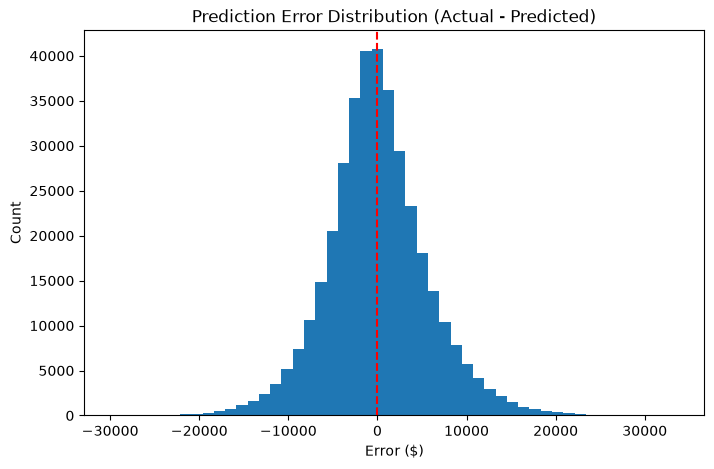

In [171]:
errors = y_test_amt2 - y_pred_nolog

plt.figure(figsize=(8,5))
plt.hist(errors, bins=50)
plt.title("Prediction Error Distribution (Actual - Predicted)")
plt.xlabel("Error ($)")
plt.ylabel("Count")
plt.axvline(0, color="red", linestyle="--")
plt.show()

In [172]:
print(X_train_amt.columns.tolist())

['term', 'int_rate', 'grade', 'sub_grade', 'emp_length', 'annual_inc', 'addr_state', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', '

In [173]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\KARTHIK\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


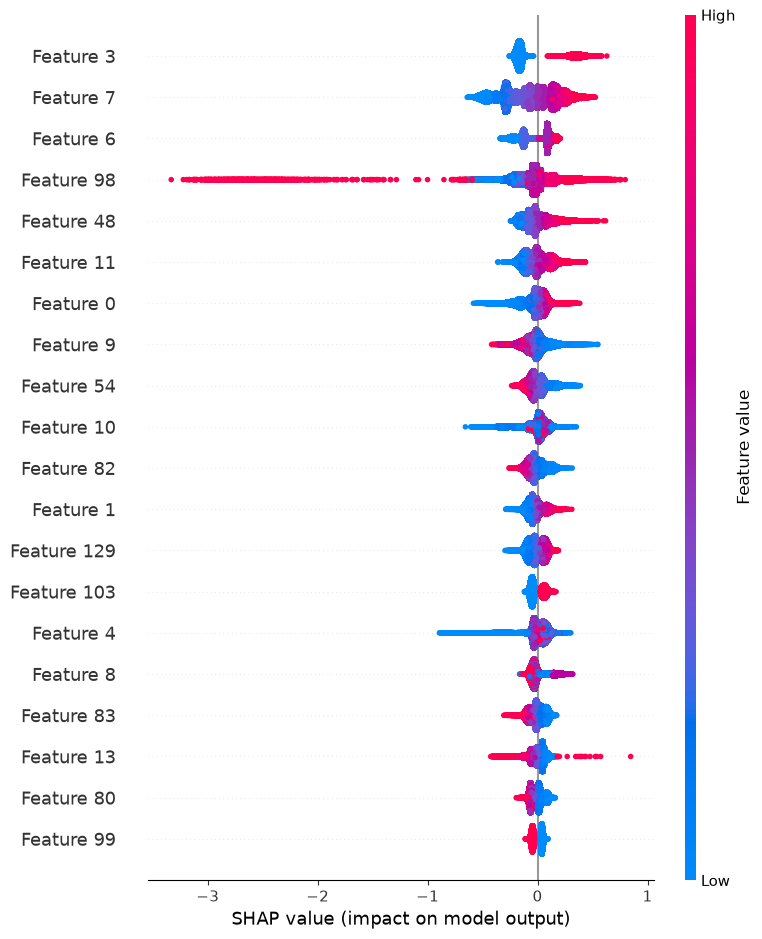

In [174]:
import shap

explainer = shap.TreeExplainer(loan_default_pipeline.named_steps["model"])
X_test_transformed = loan_default_pipeline.named_steps["preprocessor"].transform(X_test)
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed)

In [175]:
import joblib

joblib.dump(search_amt.best_estimator_, "loan_amount_model.pkl")

['loan_amount_model.pkl']

In [176]:
import joblib
import shap

loan_amount_model = joblib.load("loan_amount_model.pkl")

In [177]:
xgb_model = loan_amount_model.named_steps["model"]

In [178]:
X_test_processed = loan_amount_model.named_steps["preprocessor"].transform(X_test_amt)


In [179]:
explainer = shap.TreeExplainer(xgb_model)


In [180]:
shap_values = explainer.shap_values(X_test_processed)


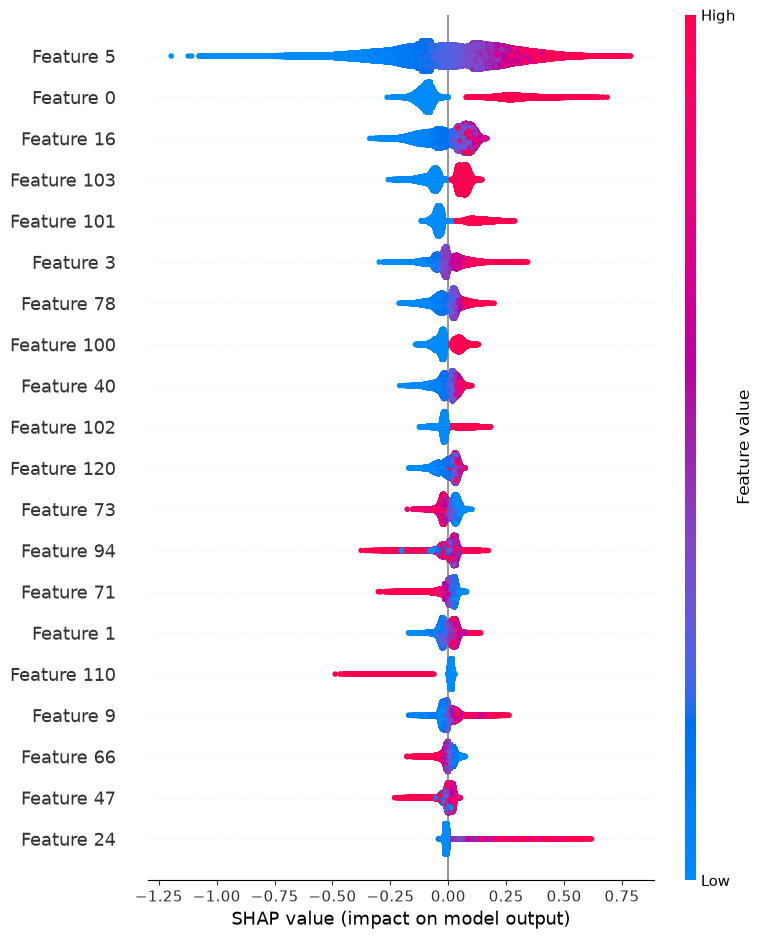

In [181]:
shap.summary_plot(shap_values, X_test_processed)

In [182]:
default_cols = loan_default_pipeline.named_steps["preprocessor"].feature_names_in_.tolist()
amount_cols = final_pipeline_log.named_steps["preprocessor"].feature_names_in_.tolist()  # or whichever regression pipeline you're keeping

print(len(default_cols), default_cols)
print(len(amount_cols), amount_cols)

131 ['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'annual_inc', 'addr_state', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_

In [183]:
import json
with open("expected_columns_default.json", "w") as f:
    json.dump(default_cols, f)
with open("expected_columns_amount.json", "w") as f:
    json.dump(amount_cols, f)